     COMPARATIVA: SOLUCIÓN ANALÍTICA VS EULER        
Tiempo (t)  T Analítica    T Euler        Error Absoluto 
-----------------------------------------------------
0.0         80.0000        80.0000        0.0000         
0.2         64.4491        62.0000        2.4491         
0.4         52.9287        49.4000        3.5287         
0.6         44.3942        40.5800        3.8142         
0.8         38.0717        34.4060        3.6657         
1.0         33.3878        30.0842        3.3036         



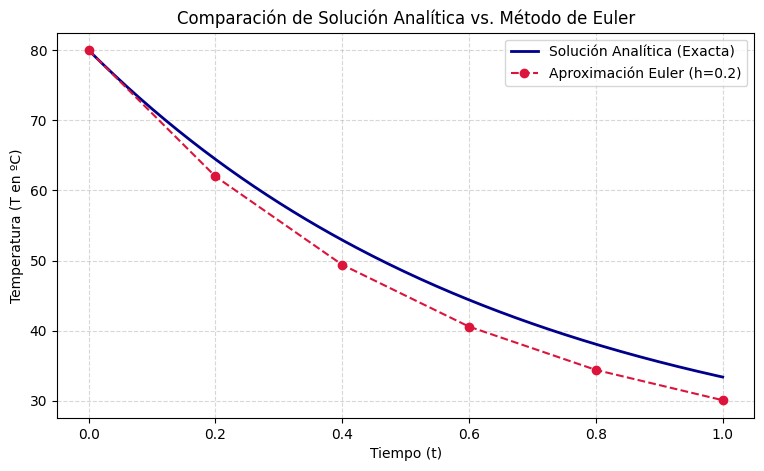

In [1]:
# =====================================================================
# ACTIVIDAD: COMPARACIÓN DE SOLUCIONES ANALÍTICAS Y NUMÉRICAS
# Problema: Ley de Enfriamiento de Newton
# Ecuación Diferencial: dT/dt = -k * (T - Ta)
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros del Problema ---
k = 1.5      # Constante de enfriamiento
Ta = 20.0    # Temperatura ambiente (ºC)
T0 = 80.0    # Temperatura inicial en t=0 (ºC)

# --- Parámetros de Simulación Solicitados ---
t_inicial = 0.0
t_final = 1.0
h = 0.2      # Tamaño del paso requerido
num_pasos = int((t_final - t_inicial) / h) + 1

# Vector de tiempo discretizado
t_num = np.linspace(t_inicial, t_final, num_pasos)

# =====================================================================
# 1. SOLUCIÓN NUMÉRICA: MÉTODO DE EULER
# =====================================================================
def dT_dt(t, T):
    return -k * (T - Ta)

T_euler = np.zeros(num_pasos)
T_euler[0] = T0

for i in range(0, num_pasos - 1):
    T_euler[i+1] = T_euler[i] + h * dT_dt(t_num[i], T_euler[i])

# =====================================================================
# 2. SOLUCIÓN ANALÍTICA (EXACTA)
# =====================================================================
# Obtenida por separación de variables: T(t) = Ta + (T0 - Ta) * e^(-kt)
def solucion_analitica(t):
    return Ta + (T0 - Ta) * np.exp(-k * t)

T_analitica = solucion_analitica(t_num)

# =====================================================================
# 3. TABLA COMPARATIVA DE RESULTADOS
# =====================================================================
print("=====================================================")
print("     COMPARATIVA: SOLUCIÓN ANALÍTICA VS EULER        ")
print("=====================================================")
print(f"{'Tiempo (t)':<12}{'T Analítica':<15}{'T Euler':<15}{'Error Absoluto':<15}")
print("-----------------------------------------------------")
for i in range(num_pasos):
    error = abs(T_analitica[i] - T_euler[i])
    print(f"{t_num[i]:<12.1f}{T_analitica[i]:<15.4f}{T_euler[i]:<15.4f}{error:<15.4f}")
print("=====================================================\n")

# =====================================================================
# 4. GENERACIÓN DE LA GRÁFICA
# =====================================================================
# Generamos un tiempo continuo para que la curva analítica se vea perfecta
t_continuo = np.linspace(t_inicial, t_final, 200)
T_analitica_curva = solucion_analitica(t_continuo)

plt.figure(figsize=(9, 5))
plt.plot(t_continuo, T_analitica_curva, color='darkblue', label='Solución Analítica (Exacta)', linewidth=2)
plt.plot(t_num, T_euler, 'o--', color='crimson', label=f'Aproximación Euler (h={h})', markersize=6)
plt.title('Comparación de Solución Analítica vs. Método de Euler')
plt.xlabel('Tiempo (t)')
plt.ylabel('Temperatura (T en ºC)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()